In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import folium
import numpy as np

In [12]:
df = pd.read_excel('dados_tuberculose_mg.xlsx')

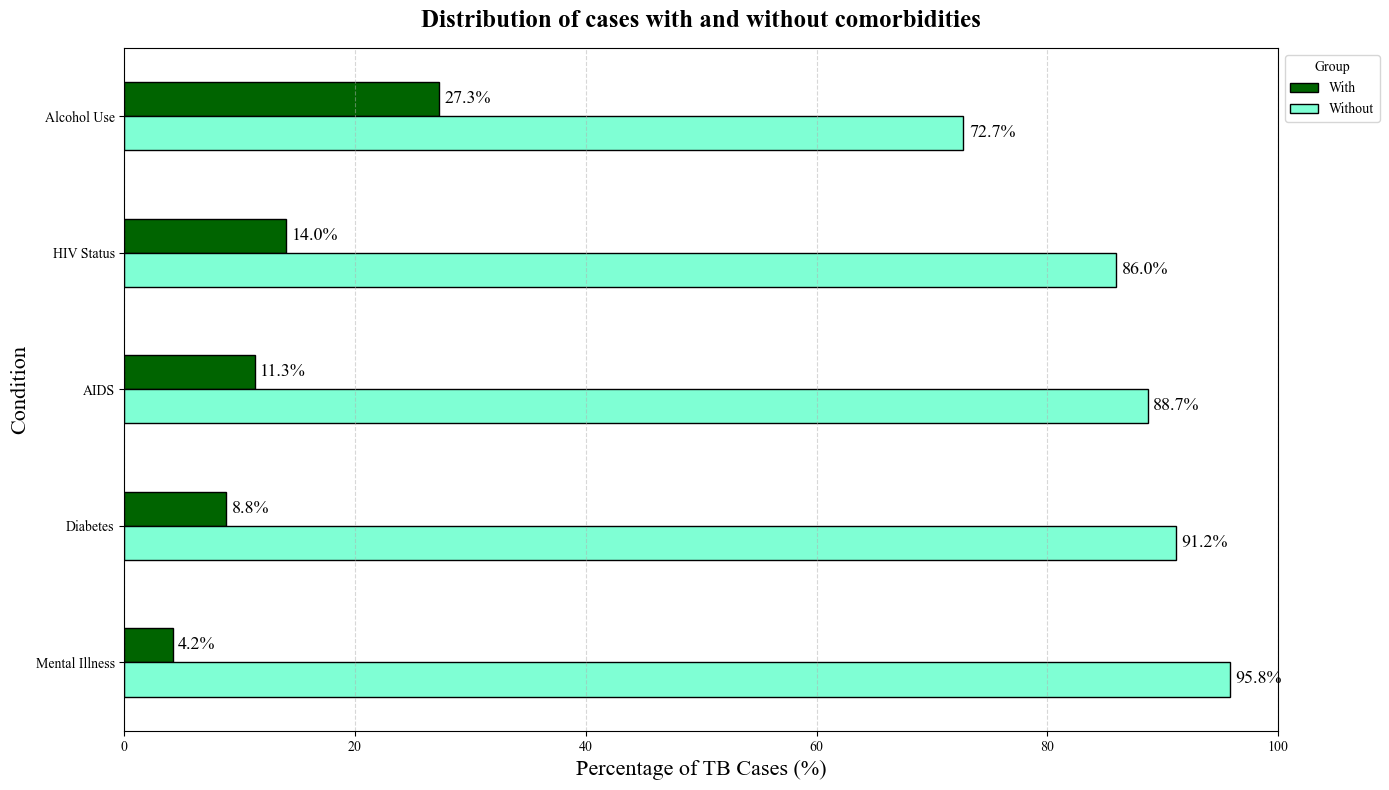

In [13]:
plt.rc('font', family='Times New Roman')

comorbidities = {
    'AGRAVAIDS': ('AIDS', ['Sim', 'Não']),
    'AGRAVALCOO': ('Alcohol Use', ['Sim', 'Não']),
    'AGRAVDIABE': ('Diabetes', ['Sim', 'Não']),
    'AGRAVDOENC': ('Mental Illness', ['Sim', 'Não']),
    'HIV': ('HIV Status', ['Positiva', 'Negativa'])
}

percentage_data = []

for column, (name, categories) in comorbidities.items():
    df_filtered = df[df[column].isin(categories)]

    percentages = (
        df_filtered[column]
        .value_counts(normalize=True)
        .reindex(categories)
        .fillna(0) * 100
    )

    for cat in categories:
        group = 'With' if cat in ['Sim', 'Positiva'] else 'Without'
        percentage_data.append({
            'Comorbidity': name,
            'Group': group,
            'Percentage': percentages[cat]
        })

df_comorb = pd.DataFrame(percentage_data)

df_pivot = (
    df_comorb
    .pivot(index='Comorbidity', columns='Group', values='Percentage')
    .sort_values(by='With', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#006400', '#7FFFD4']  # With, Without
df_pivot.plot(kind='barh', color=colors, edgecolor='black', ax=ax)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=13)

ax.set_title(
    'Distribution of cases with and without comorbidities',
    fontsize=18,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Percentage of TB Cases (%)', fontsize=16)
ax.set_ylabel('Condition', fontsize=16)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.5)

ax.legend(title='Group', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
#plt.savefig("tb_comorbidities_percentage.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

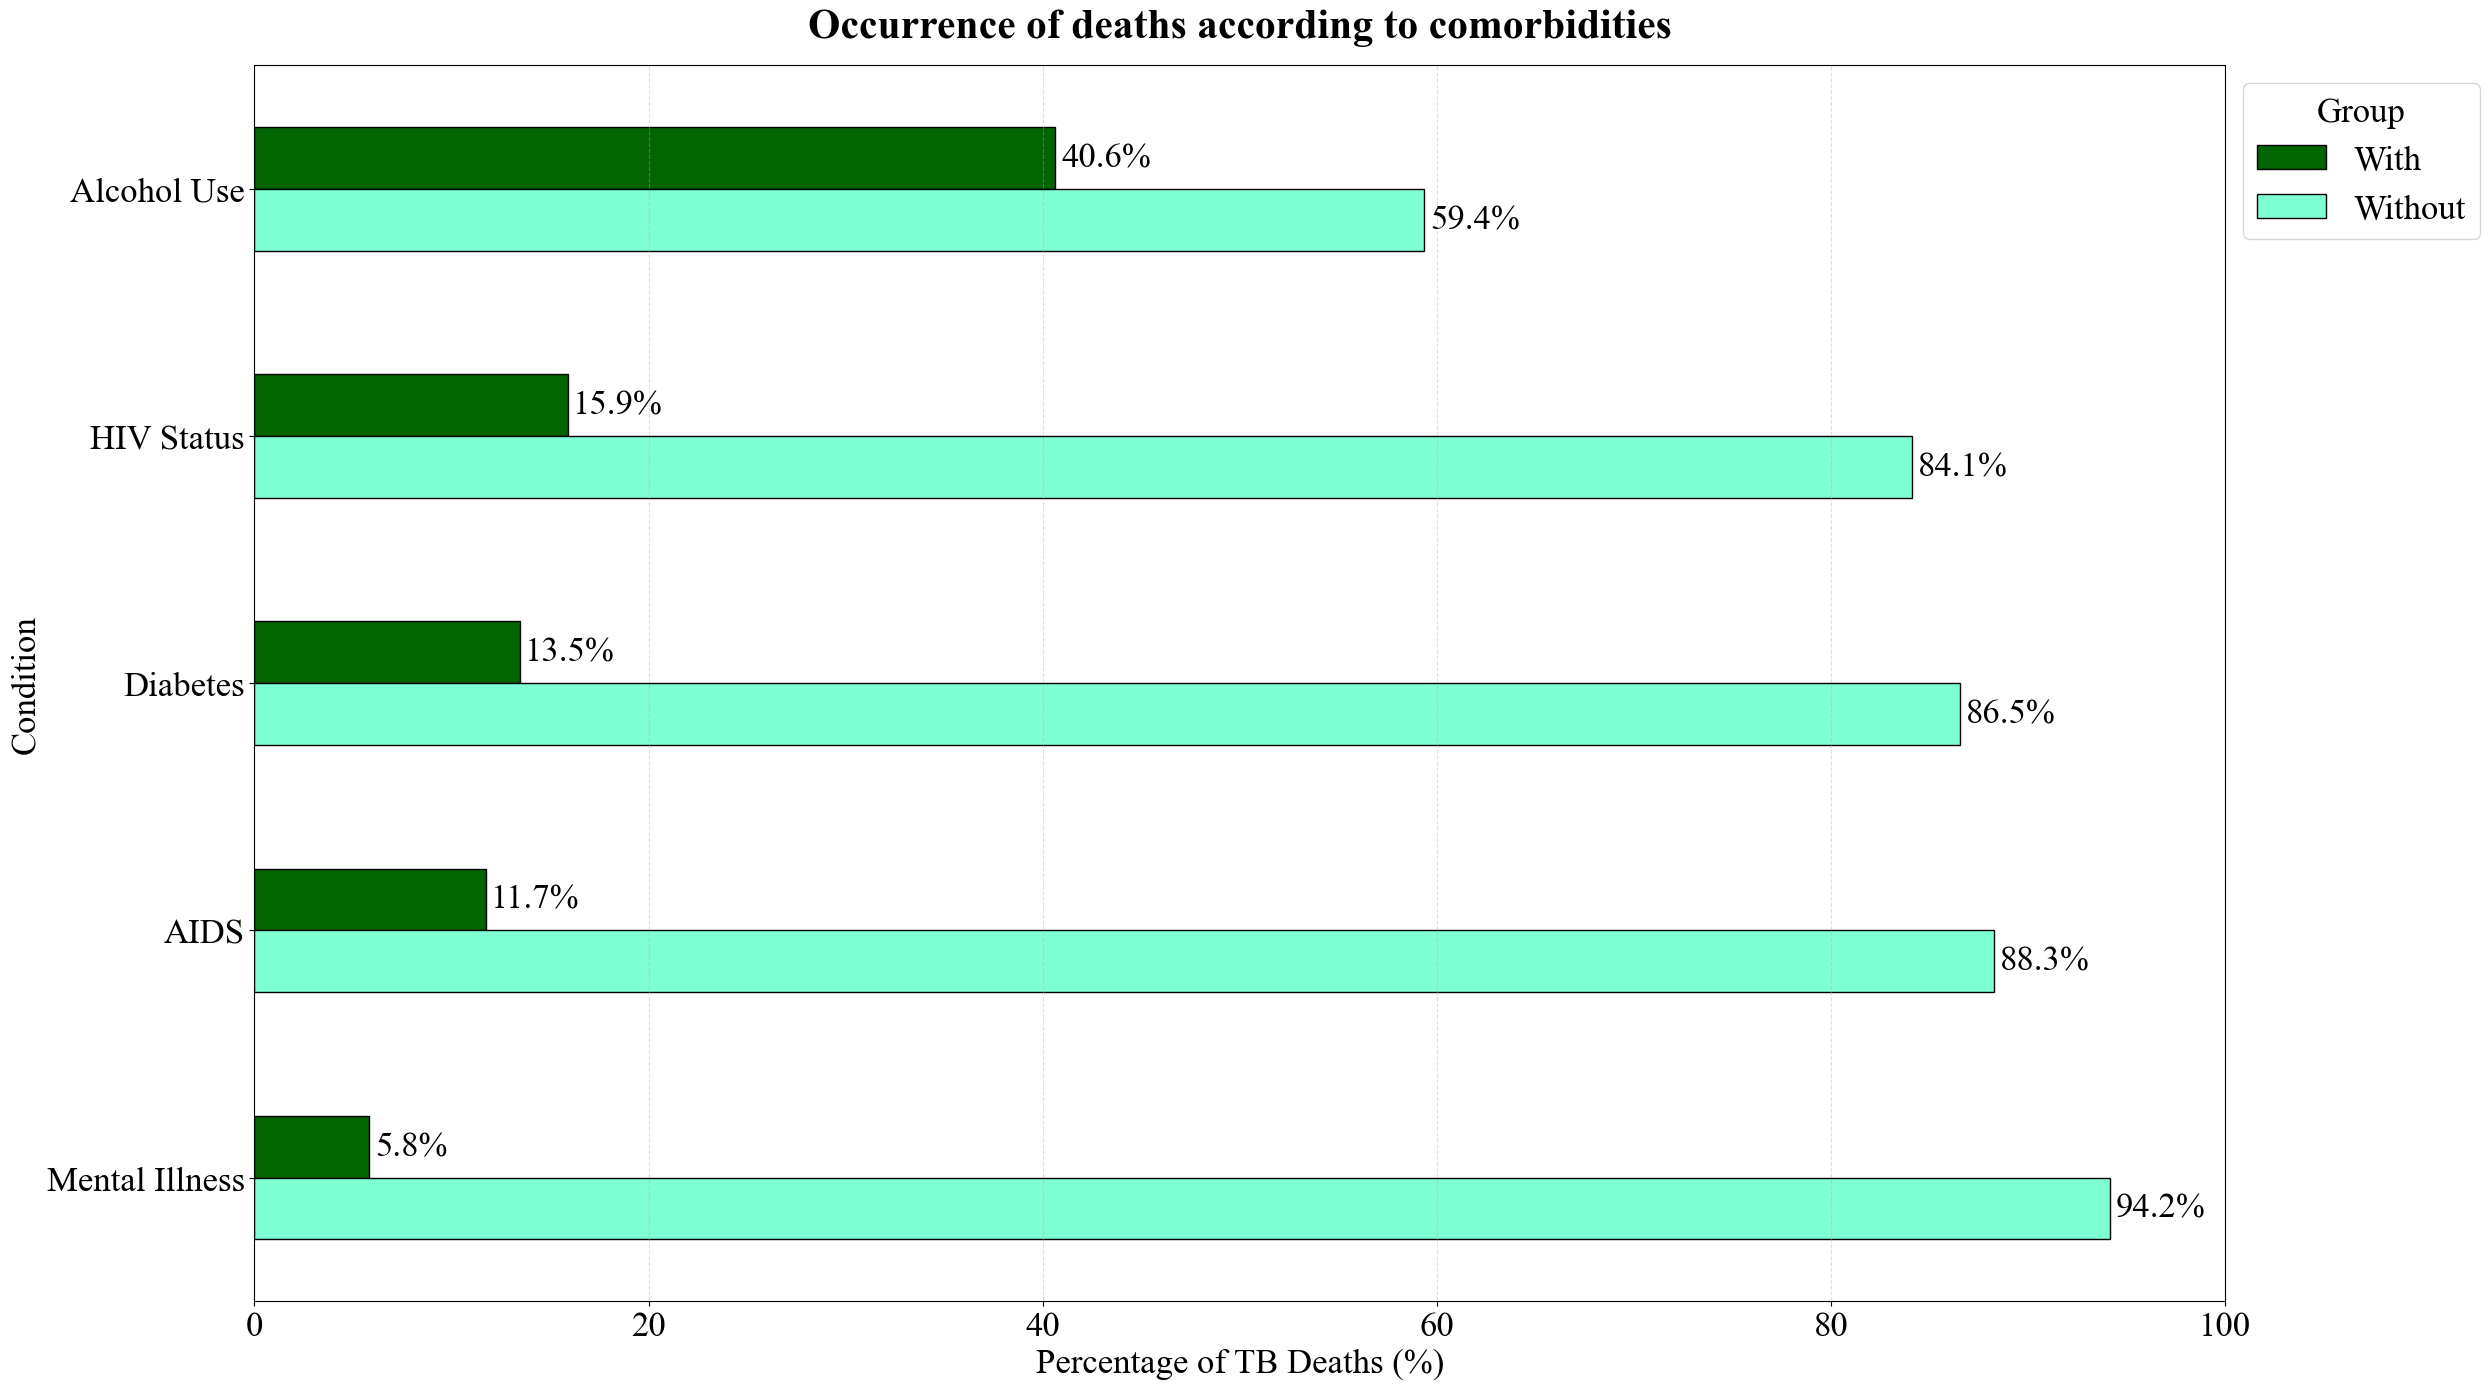

In [14]:
plt.rc('font', family='Times New Roman')

df_tb_deaths = df[df['SITUA_ENCE'] == 'Óbito por TB'].copy()

comorbidities = {
    'AGRAVAIDS': ('AIDS', ['Sim', 'Não']),
    'AGRAVALCOO': ('Alcohol Use', ['Sim', 'Não']),
    'AGRAVDIABE': ('Diabetes', ['Sim', 'Não']),
    'AGRAVDOENC': ('Mental Illness', ['Sim', 'Não']),
    'HIV': ('HIV Status', ['Positiva', 'Negativa'])
}

percentage_data = []

for column, (name, categories) in comorbidities.items():
    df_filtered = df_tb_deaths[df_tb_deaths[column].isin(categories)]

    percentages = (
        df_filtered[column]
        .value_counts(normalize=True)
        .reindex(categories)
        .fillna(0) * 100
    )

    for cat in categories:
        group = 'With' if cat in ['Sim', 'Positiva'] else 'Without'
        percentage_data.append({
            'Comorbidity': name,
            'Group': group,
            'Percentage': percentages[cat]
        })

df_comorb = pd.DataFrame(percentage_data)

df_pivot = df_comorb.pivot(index='Comorbidity', columns='Group', values='Percentage')
df_pivot = df_pivot[['With', 'Without']]  # Ensure correct order
df_pivot = df_pivot.sort_values(by='With', ascending=False)

fig, ax = plt.subplots(figsize=(25, 14))
colors = ['#006400', '#7FFFD4']  # With, Without
df_pivot.plot(kind='barh', color=colors, edgecolor='black', ax=ax)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=25)

ax.set_title(
    'Occurrence of deaths according to comorbidities',
    fontsize=30,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Percentage of TB Deaths (%)', fontsize=25)
ax.set_ylabel('Condition', fontsize=25)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x', labelsize=25)

ax.legend(
    title='Group',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=25,
    title_fontsize=25
)

plt.tight_layout()

#plt.savefig("tb_deaths_comorbidities.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

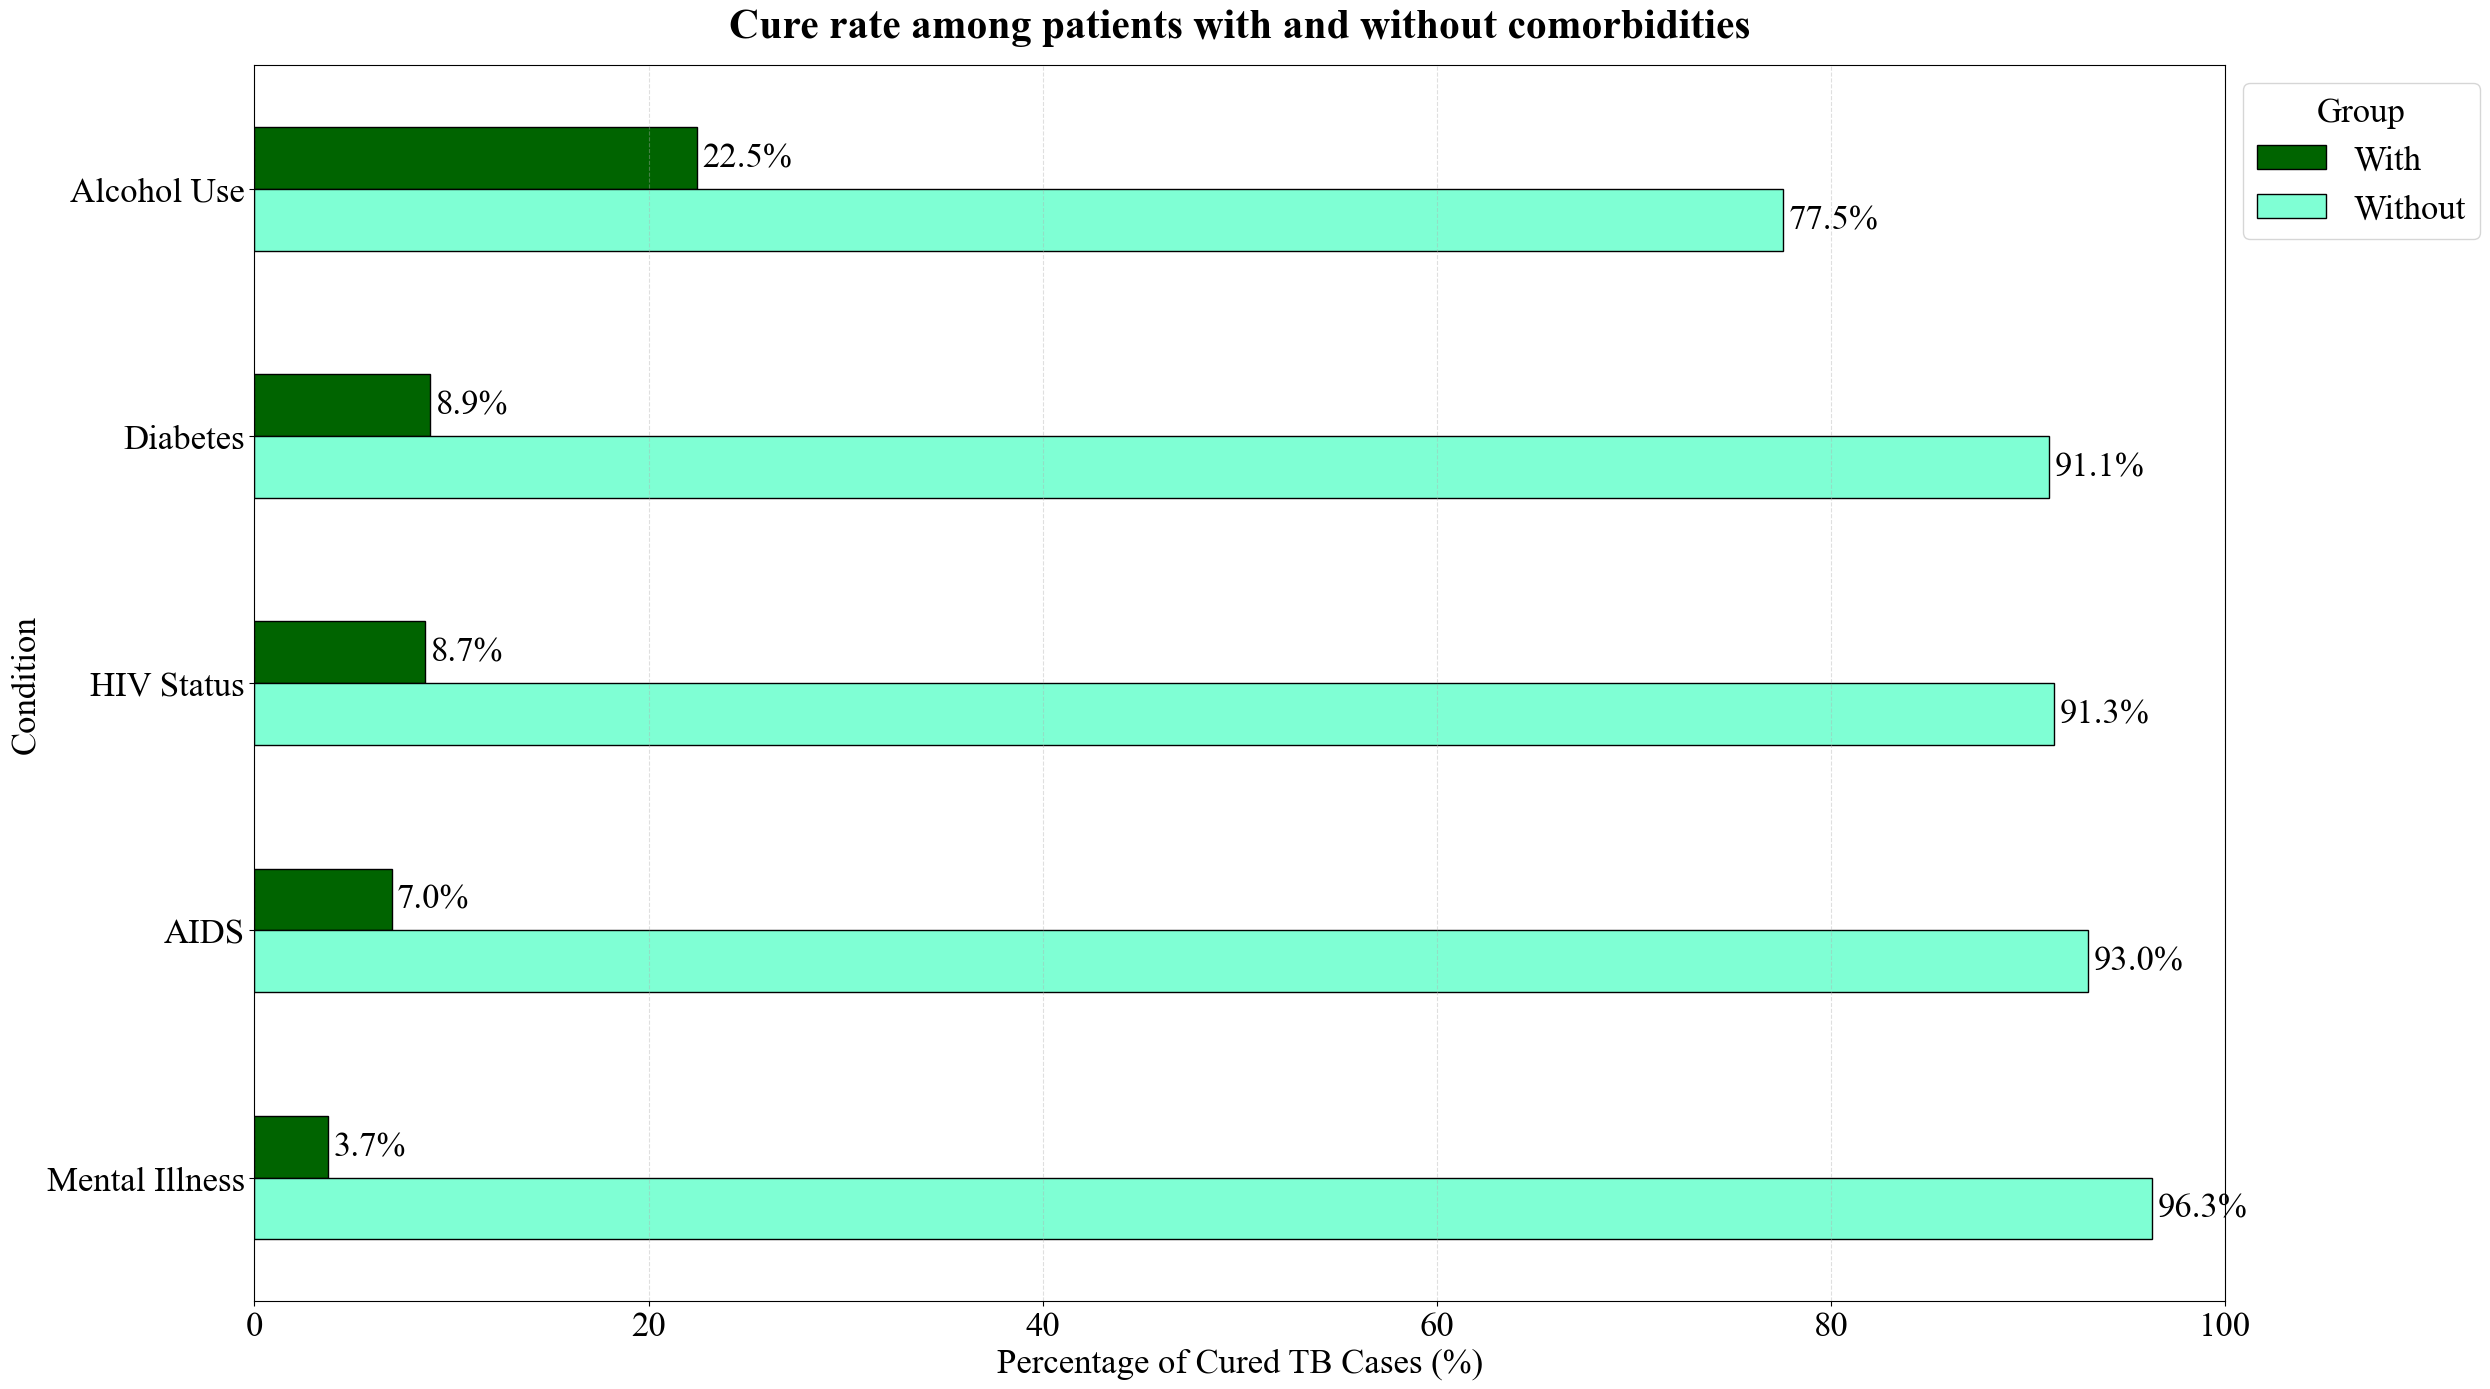

In [15]:
plt.rc('font', family='Times New Roman')

df_tb_cured = df[df['SITUA_ENCE'] == 'Cura'].copy()

comorbidities = {
    'AGRAVAIDS': ('AIDS', ['Sim', 'Não']),
    'AGRAVALCOO': ('Alcohol Use', ['Sim', 'Não']),
    'AGRAVDIABE': ('Diabetes', ['Sim', 'Não']),
    'AGRAVDOENC': ('Mental Illness', ['Sim', 'Não']),
    'HIV': ('HIV Status', ['Positiva', 'Negativa'])
}

percentage_data = []

for column, (name, categories) in comorbidities.items():
    df_filtered = df_tb_cured[df_tb_cured[column].isin(categories)]

    percentages = (
        df_filtered[column]
        .value_counts(normalize=True)
        .reindex(categories)
        .fillna(0) * 100
    )

    for cat in categories:
        group = 'With' if cat in ['Sim', 'Positiva'] else 'Without'
        percentage_data.append({
            'Comorbidity': name,
            'Group': group,
            'Percentage': percentages[cat]
        })

df_comorb = pd.DataFrame(percentage_data)

df_pivot = df_comorb.pivot(index='Comorbidity', columns='Group', values='Percentage')
df_pivot = df_pivot[['With', 'Without']]  
df_pivot = df_pivot.sort_values(by='With', ascending=False)

fig, ax = plt.subplots(figsize=(25, 14))
colors = ['#006400', '#7FFFD4']  
df_pivot.plot(kind='barh', color=colors, edgecolor='black', ax=ax)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=25)

ax.set_title(
    'Cure rate among patients with and without comorbidities',
    fontsize=30,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Percentage of Cured TB Cases (%)', fontsize=25)
ax.set_ylabel('Condition', fontsize=25)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x', labelsize=25)

ax.legend(
    title='Group',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=25,
    title_fontsize=25
)

plt.tight_layout()

#plt.savefig("tb_cured_comorbidities.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

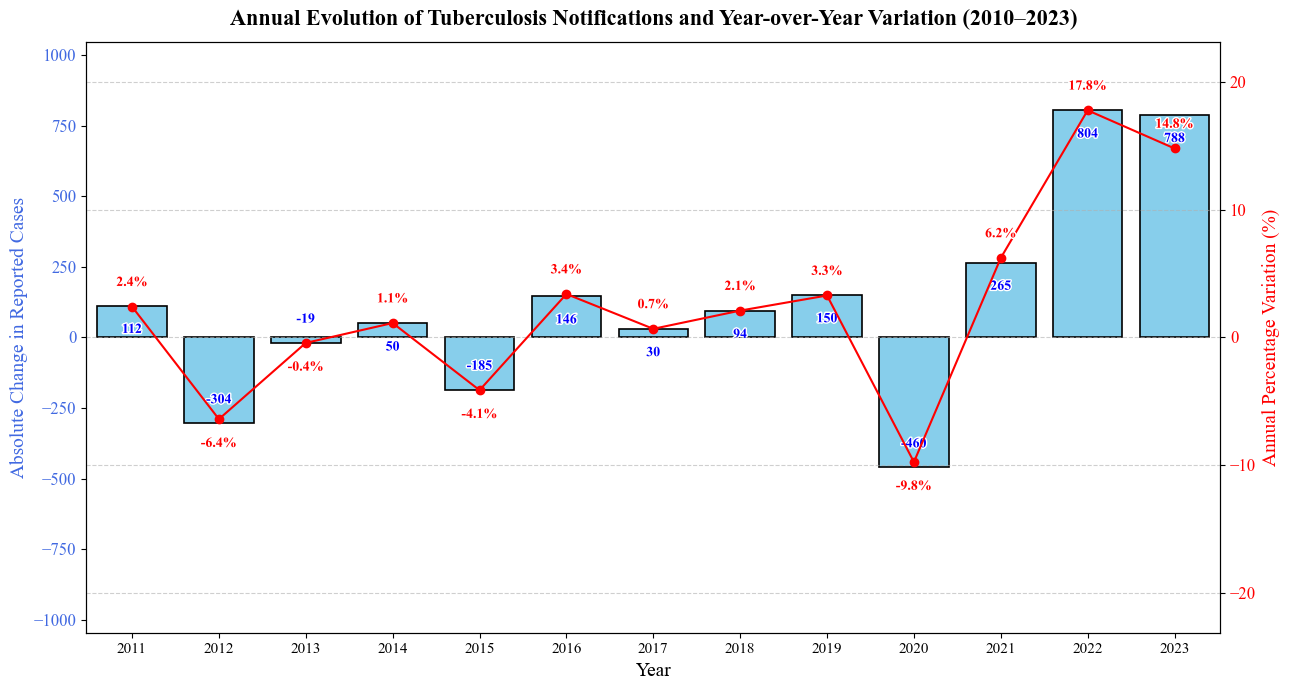

In [23]:
plt.rc('font', family='Times New Roman')

df = df[df["NU_ANO"] != 2024]

cases_per_year = df.groupby("NU_ANO").size()

all_years = range(cases_per_year.index.min(), cases_per_year.index.max() + 1)
cases_per_year = cases_per_year.reindex(all_years, fill_value=0)

absolute_variation = cases_per_year.diff()
percentage_variation = cases_per_year.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(13, 7))

bars = ax1.bar(
    cases_per_year.index,
    absolute_variation,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

ax1.set_ylabel("Absolute Change in Reported Cases", color="royalblue", fontsize=14)
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis='y', labelcolor="royalblue", labelsize=12)
ax1.tick_params(axis='x', labelsize=11)

ax1.set_xticks(list(cases_per_year.index))
ax1.set_xticklabels(cases_per_year.index)
ax1.margins(x=0.01)

ax2 = ax1.twinx()
ax2.plot(
    cases_per_year.index,
    percentage_variation,
    color="red",
    marker="o",
    linewidth=1.5
)

ax2.set_ylabel("Annual Percentage Variation (%)", color="red", fontsize=14)
ax2.tick_params(axis='y', labelcolor="red", labelsize=12)

max_abs = np.nanmax(np.abs(absolute_variation)) * 1.3
ax1.set_ylim(-max_abs, max_abs)

max_perc = np.nanmax(np.abs(percentage_variation)) * 1.3
ax2.set_ylim(-max_perc, max_perc)

for rect, val in zip(bars, absolute_variation):
    if np.isnan(val):
        continue
    height = rect.get_height()
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        height - (0.08 * max_abs if val >= 0 else -0.08 * max_abs),
        f"{int(val)}",
        ha="center",
        va="center",
        fontsize=10,
        color="blue",
        fontweight="bold",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
    )

for x, y in zip(cases_per_year.index, percentage_variation):
    if np.isnan(y) or np.isinf(y):
        continue
    offset = 0.06 * max_perc
    txt = ax2.text(
        x,
        y + offset if y >= 0 else y - offset,
        f"{y:.1f}%",
        ha="center",
        va="bottom" if y >= 0 else "top",
        fontsize=10,
        color="red",
        fontweight="bold"
    )
    txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground="white")])

plt.title(
    "Annual Evolution of Tuberculosis Notifications and Year-over-Year Variation (2010–2023)",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

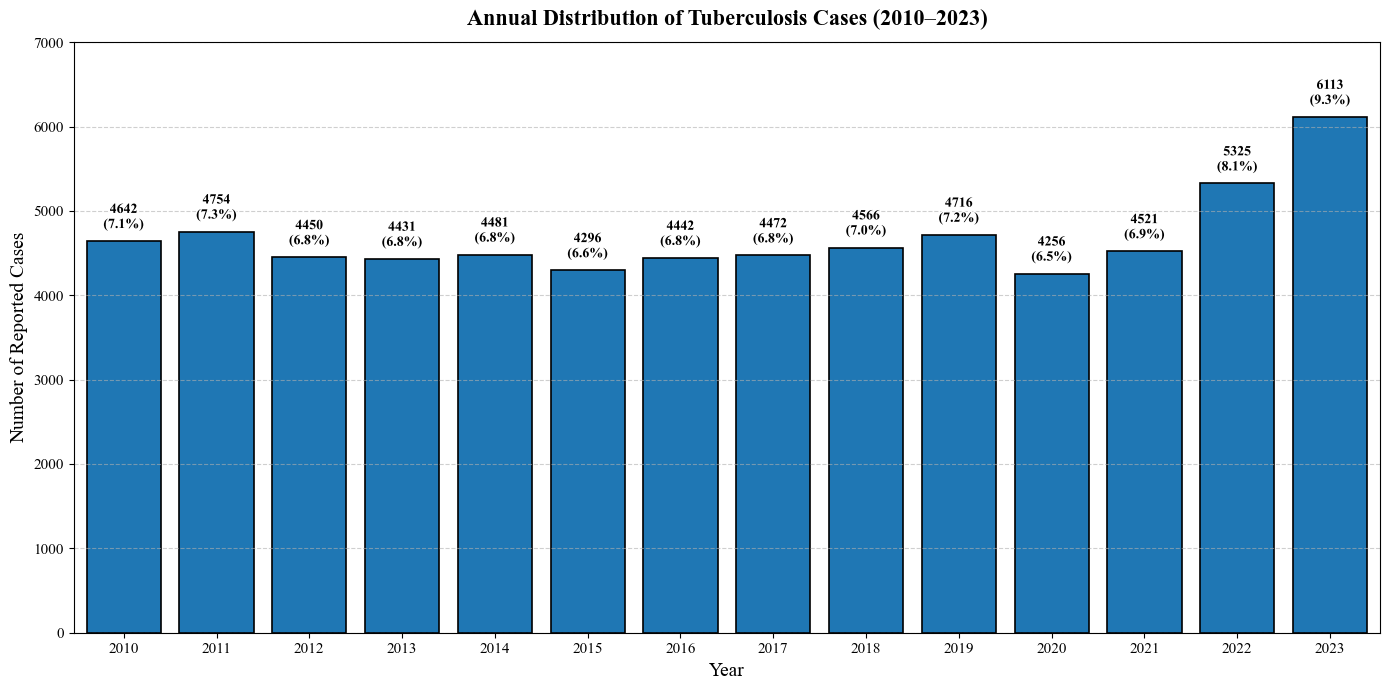

In [22]:
plt.rc('font', family='Times New Roman')

df = df[df["NU_ANO"] != 2024]

cases_per_year = df.groupby("NU_ANO").size()

all_years = range(cases_per_year.index.min(), cases_per_year.index.max() + 1)
cases_per_year = cases_per_year.reindex(all_years, fill_value=0)

total_cases = cases_per_year.sum()
percentages = (cases_per_year / total_cases) * 100

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    cases_per_year.index,
    cases_per_year.values,
    edgecolor="black",
    linewidth=1.2
)

ax.set_xticks(list(cases_per_year.index))
ax.set_xticklabels(cases_per_year.index, rotation=0)

ax.set_ylim(0, 7000)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Number of Reported Cases", fontsize=14)
ax.tick_params(axis='both', labelsize=11)
ax.margins(x=0.01)

for x, val, perc in zip(cases_per_year.index, cases_per_year.values, percentages):
    if val == 0:
        continue
    txt = ax.text(
        x,
        val + 120,
        f"{val}\n({perc:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
    txt.set_path_effects([
        path_effects.withStroke(linewidth=2, foreground="white")
    ])

plt.title(
    "Annual Distribution of Tuberculosis Cases (2010–2023)",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

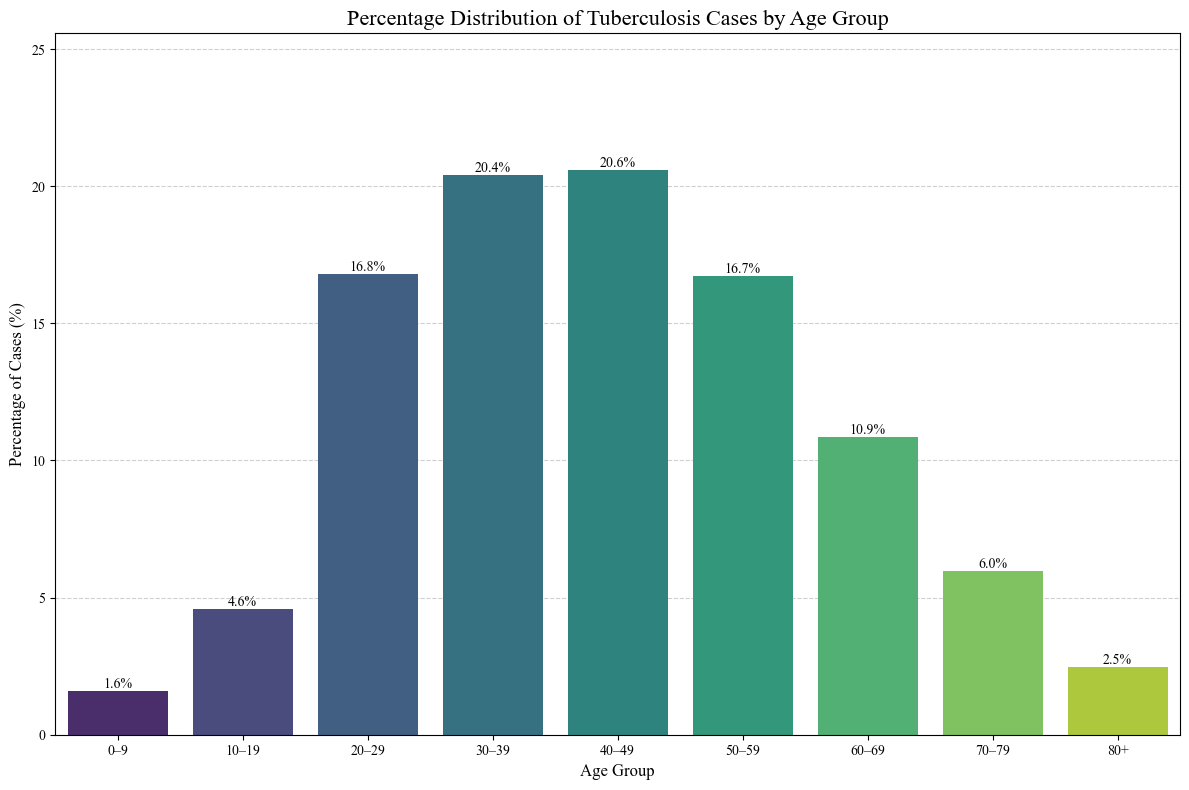

In [26]:
df['NU_IDADE_N'] = pd.to_numeric(df['NU_IDADE_N'], errors='coerce')

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 120]
labels = ['0–9', '10–19', '20–29', '30–39', '40–49', '50–59', '60–69', '70–79', '80+']
df['age_group'] = pd.cut(df['NU_IDADE_N'], bins=bins, labels=labels, right=False)

count = df['age_group'].value_counts(normalize=True).sort_index() * 100
df_pct = count.reset_index()
df_pct.columns = ['Age Group', 'Percentage']

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_pct,
    x='Age Group',
    y='Percentage',
    hue='Age Group',
    palette='viridis',
    order=labels,
    legend=False
)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Percentage Distribution of Tuberculosis Cases by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Cases (%)', fontsize=12)
plt.ylim(0, df_pct['Percentage'].max() + 5)

plt.tight_layout()
plt.show()

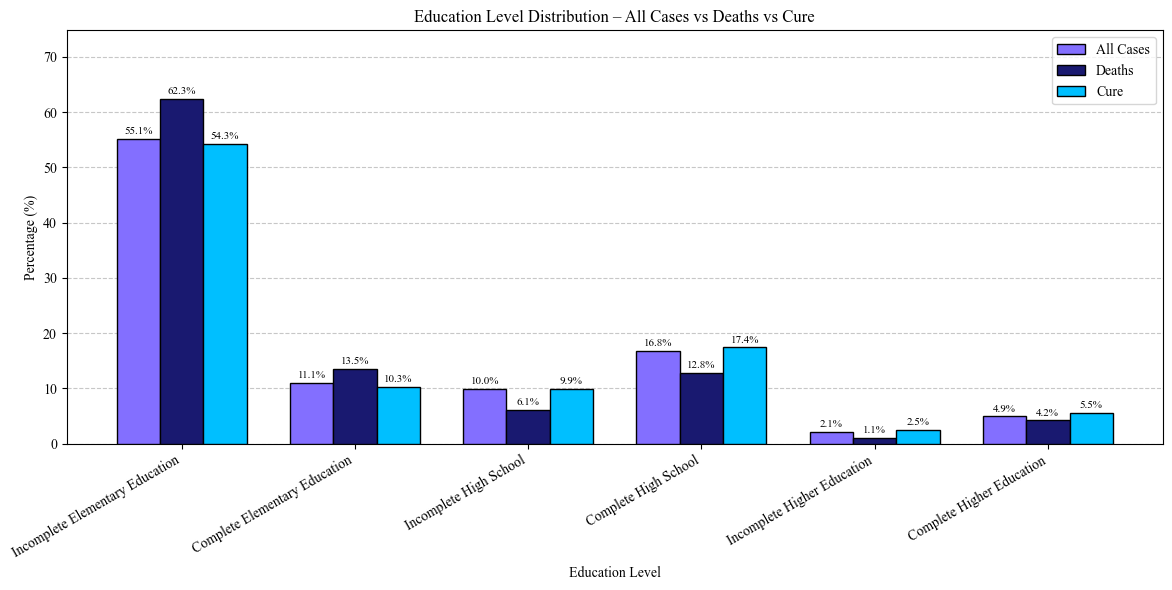

In [32]:
remove_values = ["Ignorado", "Não se aplica"]

df_filtered = df[~df["CS_ESCOL_N"].isin(remove_values)].copy()

education_map = {
    "1ª a 4ª série incompleta do EF": "Incomplete Elementary Education",
    "4ª série completa EF": "Incomplete Elementary Education",
    "5ª a 8ª série incompleta do EF": "Incomplete Elementary Education",
    "Ensino fundamental completo": "Complete Elementary Education",
    "Ensino médio incompleto": "Incomplete High School",
    "Ensino médio completo": "Complete High School",
    "Educação superior incompleta": "Incomplete Higher Education",
    "Educação superior completa": "Complete Higher Education"
}

df_filtered["EDUCATION_CAT"] = df_filtered["CS_ESCOL_N"].map(education_map)

total_pct = df_filtered["EDUCATION_CAT"].value_counts(normalize=True) * 100

df_deaths = df[df["SITUA_ENCE"].isin(["Óbito por tuberculose", "Óbito por outras causas"])].copy()
df_deaths["EDUCATION_CAT"] = df_deaths["CS_ESCOL_N"].map(education_map)
df_deaths = df_deaths.dropna(subset=["EDUCATION_CAT"])

deaths_pct = df_deaths["EDUCATION_CAT"].value_counts(normalize=True) * 100

df_cure = df[df["SITUA_ENCE"] == "Cura"].copy()
df_cure["EDUCATION_CAT"] = df_cure["CS_ESCOL_N"].map(education_map)
df_cure = df_cure.dropna(subset=["EDUCATION_CAT"])

cure_pct = df_cure["EDUCATION_CAT"].value_counts(normalize=True) * 100

order = [
    "Incomplete Elementary Education",
    "Complete Elementary Education",
    "Incomplete High School",
    "Complete High School",
    "Incomplete Higher Education",
    "Complete Higher Education"
]

total_pct = total_pct.reindex(order)
deaths_pct = deaths_pct.reindex(order)
cure_pct = cure_pct.reindex(order)

x = range(len(order))
width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    [i - width for i in x],
    total_pct.values,
    width=width,
    label="All Cases",
    edgecolor="black",
    zorder=3,
    color=['#836FFF']
)

bars2 = plt.bar(
    x,
    deaths_pct.values,
    width=width,
    label="Deaths",
    edgecolor="black",
    zorder=3,
    color=['#191970']
)

bars3 = plt.bar(
    [i + width for i in x],
    cure_pct.values,
    width=width,
    label="Cure",
    edgecolor="black",
    zorder=3,
    color=['#00BFFF']
)

plt.grid(axis="y", linestyle="--", alpha=0.7, zorder=0)

plt.ylim(0, max(total_pct.max(), deaths_pct.max(), cure_pct.max()) * 1.2)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if pd.notna(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

plt.xticks(x, order, rotation=30, ha="right")
plt.ylabel("Percentage (%)")
plt.xlabel("Education Level")
plt.title("Education Level Distribution – All Cases vs Deaths vs Cure")
plt.legend()
plt.tight_layout()
plt.savefig(
    "education_level_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

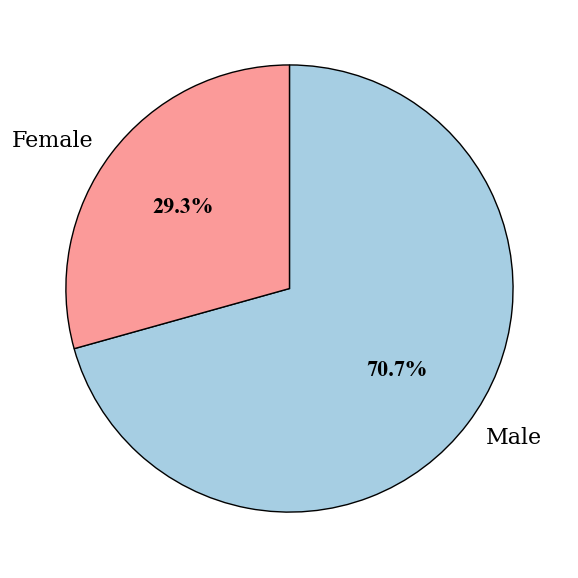

In [30]:
df = pd.read_excel(r'C:\Users\Usuario\Documents\TCC\Datasetok\dados_tuberculose_mg.xlsx')

sex_map = {
    "M": "Male",
    "F": "Female",
    "Masculino": "Male",
    "Feminino": "Female"
}

df['SEX_EN'] = df['CS_SEXO'].map(sex_map)

sex_pct = df['SEX_EN'].dropna().value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 6))

colors = ["#a6cee3", "#fb9a99"]

wedges, texts, autotexts = ax.pie(
    sex_pct,
    labels=sex_pct.index,
    autopct="%.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "black"}
)

plt.setp(texts, fontsize=16, fontfamily="serif")
plt.setp(autotexts, fontsize=16, fontweight="bold", color="black")

plt.tight_layout()
plt.show()

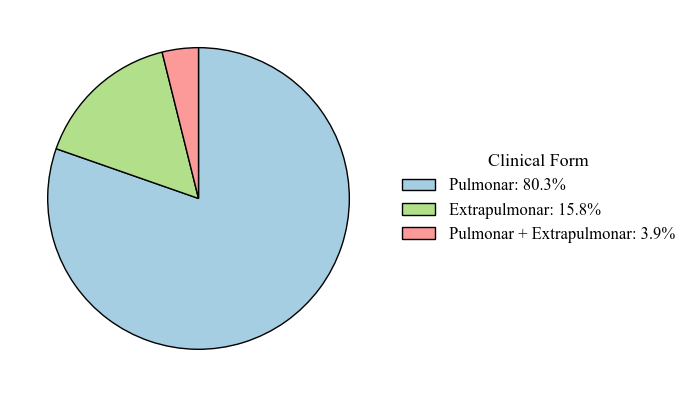

In [31]:
form_pct = (
    df[df["FORMA"] != "Ignorado"]["FORMA"]
    .value_counts(normalize=True)
    * 100
)

fig, ax = plt.subplots(figsize=(7, 7))

colors = ["#a6cee3", "#b2df8a", "#fb9a99", "#fdbf6f", "#cab2d6"]

wedges, _ = ax.pie(
    form_pct.values,
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "black"}
)

legend_labels = [
    f"{label}: {value:.1f}%"
    for label, value in zip(form_pct.index, form_pct.values)
]

ax.legend(
    wedges,
    legend_labels,
    title="Clinical Form",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=12,
    title_fontsize=13
)

plt.tight_layout()
plt.show()

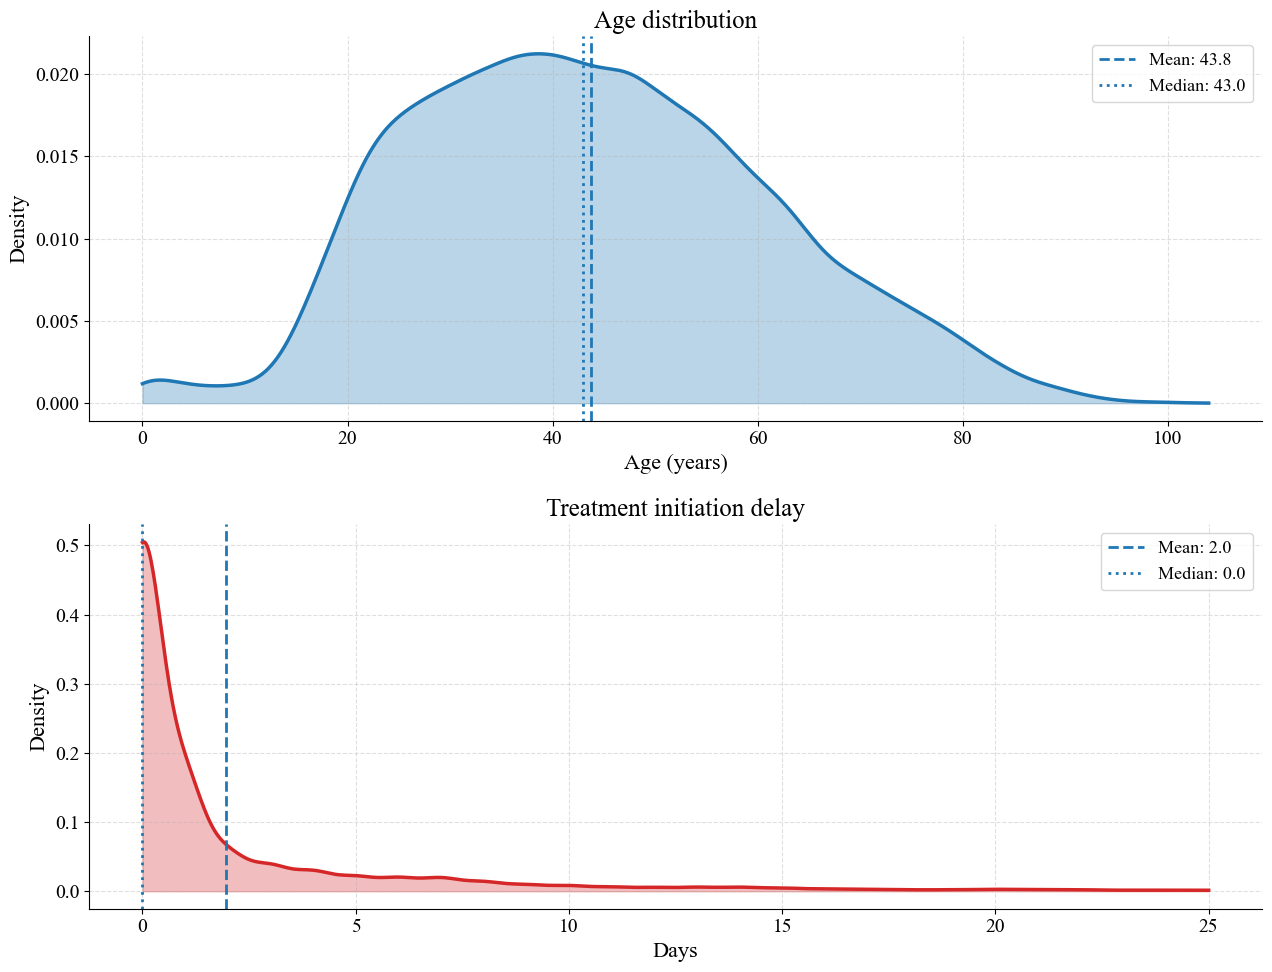

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import unidecode

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13
})

df = pd.read_excel('dados_tuberculose_mg.xlsx')

def limpar_texto(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = unidecode.unidecode(x)
    x = x.replace(" ", "_")
    return x

colunas_categoricas = df.select_dtypes(include=["object", "string"]).columns

for col in colunas_categoricas:
    df[col] = df[col].apply(limpar_texto)

categorias_validas = ["Cura", "Obito_por_TB", "Obito_por_outras_causas", "Abandono"]
df = df[df["SITUA_ENCE"].isin(categorias_validas)].copy()

df["DT_DIAG"] = pd.to_datetime(df["DT_DIAG"], format="%d/%m/%Y", errors="coerce")
df["DT_INIC_TR"] = pd.to_datetime(df["DT_INIC_TR"], format="%d/%m/%Y", errors="coerce")

df["tempo_inicio_trat"] = (df["DT_INIC_TR"] - df["DT_DIAG"]).dt.days

df = df.drop_duplicates()
df = df[df["tempo_inicio_trat"].notna()]
df = df[df["tempo_inicio_trat"] >= 0]
df = df[df["tempo_inicio_trat"] <= 25]

age = df["NU_IDADE_N"].dropna()
treatment_delay = df["tempo_inicio_trat"]

color_age = "#1f77b4"
color_delay = "#d62728"

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

x_age = np.linspace(age.min(), age.max(), 1000)
kde_age = gaussian_kde(age)

axes[0].plot(x_age, kde_age(x_age), color=color_age, linewidth=2.5)
axes[0].fill_between(x_age, kde_age(x_age), color=color_age, alpha=0.3)

axes[0].axvline(age.mean(), linestyle="--", linewidth=2, label=f"Mean: {age.mean():.1f}")
axes[0].axvline(age.median(), linestyle=":", linewidth=2, label=f"Median: {age.median():.1f}")

axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Density")
axes[0].legend()

x_delay = np.linspace(treatment_delay.min(), treatment_delay.max(), 1000)
kde_delay = gaussian_kde(treatment_delay)

axes[1].plot(x_delay, kde_delay(x_delay), color=color_delay, linewidth=2.5)
axes[1].fill_between(x_delay, kde_delay(x_delay), color=color_delay, alpha=0.3)

axes[1].axvline(treatment_delay.mean(), linestyle="--", linewidth=2,
                label=f"Mean: {treatment_delay.mean():.1f}")
axes[1].axvline(treatment_delay.median(), linestyle=":", linewidth=2,
                label=f"Median: {treatment_delay.median():.1f}")

axes[1].set_title("Treatment initiation delay")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Density")
axes[1].legend()

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("probability_density_function.pdf", dpi=300)
plt.show()